In [82]:
import matplotlib.pyplot as plt
import pandas as pd
import os


In [83]:
filepath = "results/results.csv"
df = pd.read_csv(filepath)
df.head(5)

,instance,method,run,seed,makespan,decode_calls,time,lower_bound,optimum,optimum_source
0,mini3,local_search,0,7,11,200000,0.878,10,11,bruteforce
1,mini3,local_search,1,1007,11,200000,0.871,10,11,bruteforce
2,mini3,local_search,2,2007,11,200000,0.891,10,11,bruteforce
3,mini3,local_search,3,3007,11,200000,0.830,10,11,bruteforce
4,mini3,local_search,4,4007,11,200000,0.832,10,11,bruteforce


In [84]:
df["gap"] = (df.makespan - df.optimum) / df.optimum * 100

In [85]:
METHOD_NAME = {
    "annealing": "Annealing",
    "vns": "VNS",
    "ga": "GA",
    "local_search": "Loc. Search"
}
df["method"] = df.method.map(METHOD_NAME)

df.to_csv("data/results-transformed.csv", index=False)


In [86]:

df = pd.read_csv("data/results-transformed.csv")

In [87]:
PROBLEMS = ["mini3", "ft06","la01","la02","la03","la04","la05","ft10","ft20"]
METHODS = ["Annealing", "VNS", "Genetic Algorithm", "Loc. Search"]

/tmp/ipykernel_1533207/1817487897.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8,loc="lower right")
/tmp/ipykernel_1533207/1817487897.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8,loc="lower right")
/tmp/ipykernel_1533207/1817487897.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8,loc="lower right")
/tmp/ipykernel_1533207/1817487897.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8,loc="lo

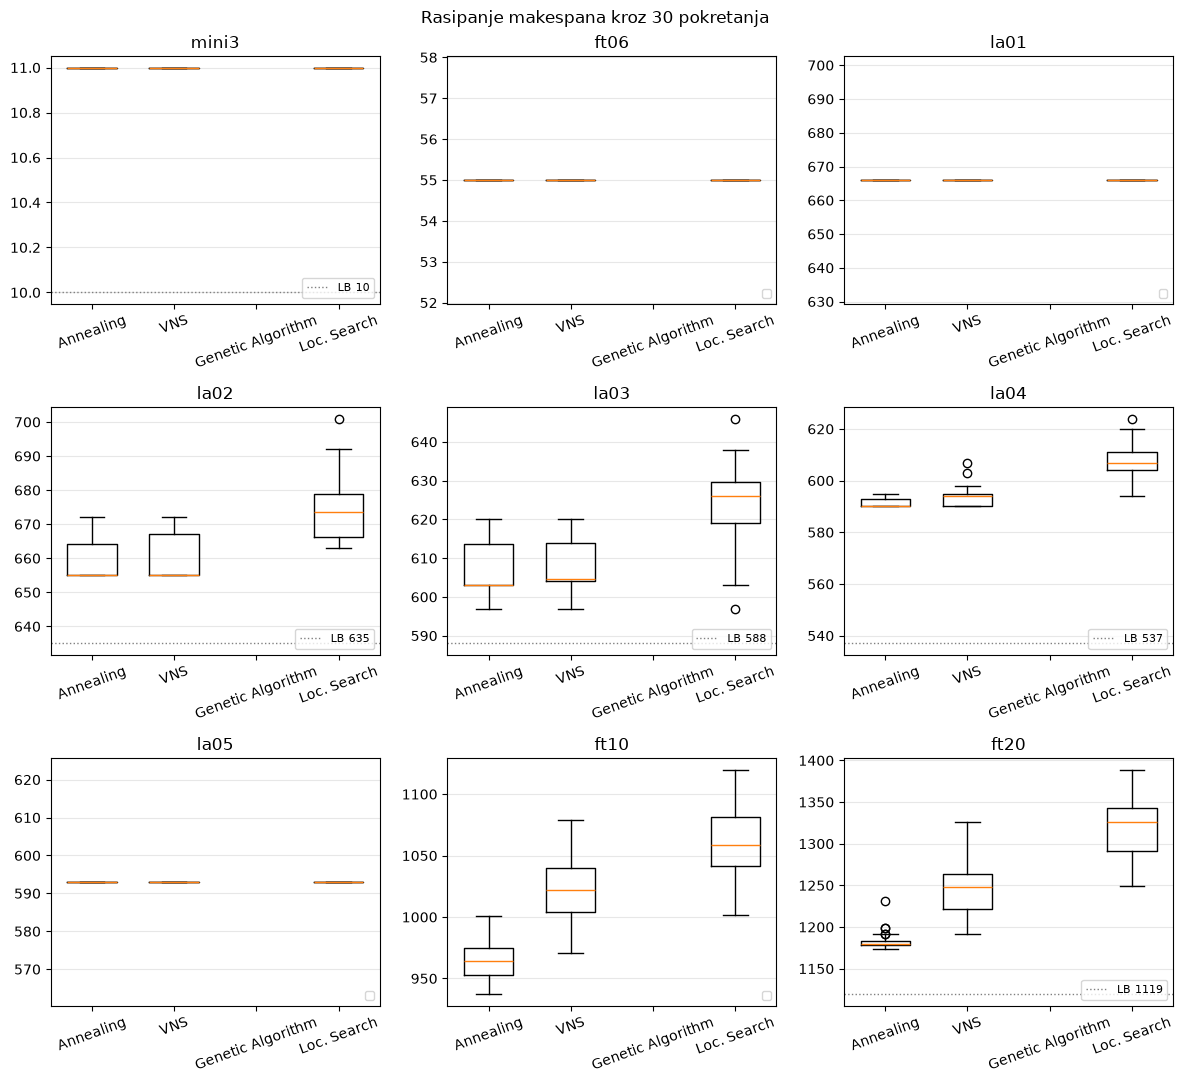

In [88]:
fig, axes = plt.subplots(3,3,figsize=(12,11))
for ax, inst in zip(axes.ravel(), PROBLEMS):
    d = df[df.instance == inst]

    ax.boxplot([d[d.method == m].makespan for m in METHODS],
               tick_labels=METHODS, widths=0.6)

    opt = d.optimum.iloc[0]
    lb = d.lower_bound.iloc[0]

    if 0 < (opt - lb) / opt < 0.10:
        ax.axhline(lb, ls=":", c="0.5", lw=1, label=f"LB {lb}")

    ax.set_title(inst)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x",labelsize=10,rotation=20)
    ax.legend(fontsize=8,loc="lower right")

fig.suptitle("Rasipanje makespana kroz 30 pokretanja")
plt.tight_layout()


In [89]:
d = df.groupby(["instance", "method"]).makespan.describe()
d.head()

count        mean        std    min    25%    50%  \
instance method                                                           
ft06     Annealing     30.0   55.000000   0.000000   55.0   55.0   55.0   
         GA            30.0   55.000000   0.000000   55.0   55.0   55.0   
         Loc. Search   30.0   55.000000   0.000000   55.0   55.0   55.0   
         VNS           30.0   55.000000   0.000000   55.0   55.0   55.0   
ft10     Annealing     30.0  965.166667  16.263103  937.0  953.0  964.5   

                        75%     max  
instance method                      
ft06     Annealing     55.0    55.0  
         GA            55.0    55.0  
         Loc. Search   55.0    55.0  
         VNS           55.0    55.0  
ft10     Annealing    975.0  1001.0

In [93]:
t2 = d["min"].unstack().reindex(PROBLEMS)
meta = df.groupby("instance")[["lower_bound","optimum"]].first().reindex(PROBLEMS)
t2 = pd.concat([meta,t2], axis=1)
t2

,lower_bound,optimum,Annealing,GA,Loc. Search,VNS
instance,,,,,,
mini3,10,11,11.0,11.0,11.0,11.0
ft06,47,55,55.0,55.0,55.0,55.0
la01,666,666,666.0,666.0,666.0,666.0
la02,635,655,655.0,655.0,663.0,655.0
la03,588,597,597.0,604.0,597.0,597.0
la04,537,590,590.0,590.0,594.0,590.0
la05,593,593,593.0,593.0,593.0,593.0
ft10,655,930,937.0,961.0,1002.0,971.0
ft20,1119,1165,1173.0,1180.0,1249.0,1192.0


In [ ]:
extra = df.groupby(["instance","method"]).apply(
    lambda g: pd.Series({
        "hits": int((g.makespan == g.optimum).sum()),
        "opt. deviation": round((g.makespan - g.optimum).mean() / g.optimum.iloc[0] * 100,2),
        "time": round(g.time.mean(), 2)}),
    include_groups=False
)

t3 = pd.concat(
    [d[["min","mean","std","50%"]].round(2), extra], axis=1
).reindex(PROBLEMS, level = 0)